In [1]:
import netplotbrain
import pandas as pd
import nibabel as nib
import numpy as np
import os
from nichord.chord import plot_chord
from nichord.convert import convert_matrix

/local/scratch/.cache/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-e_iff_0_ because there was an issue with the default path (/local/scratch/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
datasets=['HCP','LOBE']

In [3]:
# Pattern
fc_pattern='results/{dataset}/sub-{subject}/func/sub-{subject}_task-rest_den-91k_desc-preproc_denoise-24HMP8PhysSpikeReg_fwhm-5_atlas-brainnetome_bold.pconn.nii'
sc_pattern='results/{dataset}/sub-{subject}/dwi/sub-{subject}_den-91k_atlas-brainnetome_struc.pconn.nii'
#sfc_pattern='results/{dataset}/sub-{subject}/func/sub-{subject}_task-rest_den-91k_desc-preproc_denoise-24HMP8PhysSpikeReg_fwhm-5_atlas-brainnetome_sfc.pscalar.nii'


# SC #

In [24]:

# Function to load all subject connection matrices
def load_conn_matrices(subjects, conn_file_func):
    conn_matrices = []
    for subject in subjects:
        conn_matrix_path = conn_file_func(subject)
        conn_matrix = nib.load(conn_matrix_path).get_fdata()
        conn_matrices.append(conn_matrix)
    return np.array(conn_matrices)

# Function to load the labels (from a single label tsv)
def load_labels(label_file):
    df = pd.read_csv(label_file, sep='\t')
    if 'networks' in df.columns:
        idx_to_label = {idx: label for idx, label in zip(df.index, df.networks)}
    else:
        raise ValueError(f'No networks defined in {label_file}')
    return idx_to_label

# Function to calculate the average connection matrix
def average_conn_matrix(conn_matrices):
    return np.mean(conn_matrices, axis=0)

# Define the subjects for each dataset
lobe_subjects = ['007', '009', '013']  # Replace with actual subject names for LOBE
hcp_subjects = ['HCD2901654', 'HCD0551946', 'HCD1010412']  # Replace with actual subject names for HCP

# Define file paths (customize as needed)
lobe_label_file = 'resources/atlas/atlas-brainnetome_dseg.tsv'  # LOBE label file
hcp_label_file = 'resources/atlas/atlas-brainnetome_dseg.tsv'   # HCP label file
lobe_conn_file_func = lambda subject: f'results/LOBE/sub-{subject}/dwi/sub-{subject}_den-91k_atlas-brainnetome_struc.pconn.nii'
hcp_conn_file_func = lambda subject: f'results/HCP/sub-{subject}/dwi/sub-{subject}_den-91k_atlas-brainnetome_struc.pconn.nii'

# Load the labels for LOBE and HCP datasets
lobe_labels = load_labels(lobe_label_file)
hcp_labels = load_labels(hcp_label_file)

# Load connection matrices for all subjects in each dataset
lobe_conn_matrices = load_conn_matrices(lobe_subjects, lobe_conn_file_func)
hcp_conn_matrices = load_conn_matrices(hcp_subjects, hcp_conn_file_func)

# Compute the average connectivity matrix for each dataset
lobe_avg_conn = average_conn_matrix(lobe_conn_matrices)
hcp_avg_conn = average_conn_matrix(hcp_conn_matrices)

# Plot the chord diagrams for each dataset
opts = {
    'edge_widthscale': 0.001,  # Example option, customize as needed
    'edge_threshold': 100,
    'view': 'LSc',
    'edge_thresolddirection': 'above',
    'figsize': (10, 10)
}

# Convert the average connectivity matrices for both LOBE and HCP
lobe_edges, lobe_edge_weights = convert_matrix(lobe_avg_conn)
hcp_edges, hcp_edge_weights = convert_matrix(hcp_avg_conn)

# Apply the edge width scaling
lobe_edge_weights = lobe_edge_weights * opts['edge_widthscale']
hcp_edge_weights = hcp_edge_weights * opts['edge_widthscale']

# Define output paths for the plots
lobe_output_path = 'lobe_sc_avg_chord_plot.png'  # Path to save LOBE plot
hcp_output_path = 'hcp_sc_avg_chord_plot.png'    # Path to save HCP plot

# Plot the chord diagrams for LOBE and HCP
plot_chord(idx_to_label=lobe_labels, edges=lobe_edges, edge_weights=lobe_edge_weights, fp_chord=lobe_output_path)
plot_chord(idx_to_label=hcp_labels, edges=hcp_edges, edge_weights=hcp_edge_weights, fp_chord=hcp_output_path)

# Print paths of saved plots
print(f"Chord plot for LOBE dataset saved at: {lobe_output_path}")
print(f"Chord plot for HCP dataset saved at: {hcp_output_path}")


Chord plot for LOBE dataset saved at: lobe_sc_avg_chord_plot.png
Chord plot for HCP dataset saved at: hcp_sc_avg_chord_plot.png


<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

# FC #

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f2cc0ce4180> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

<Figure size 1500x1500 with 0 Axes>

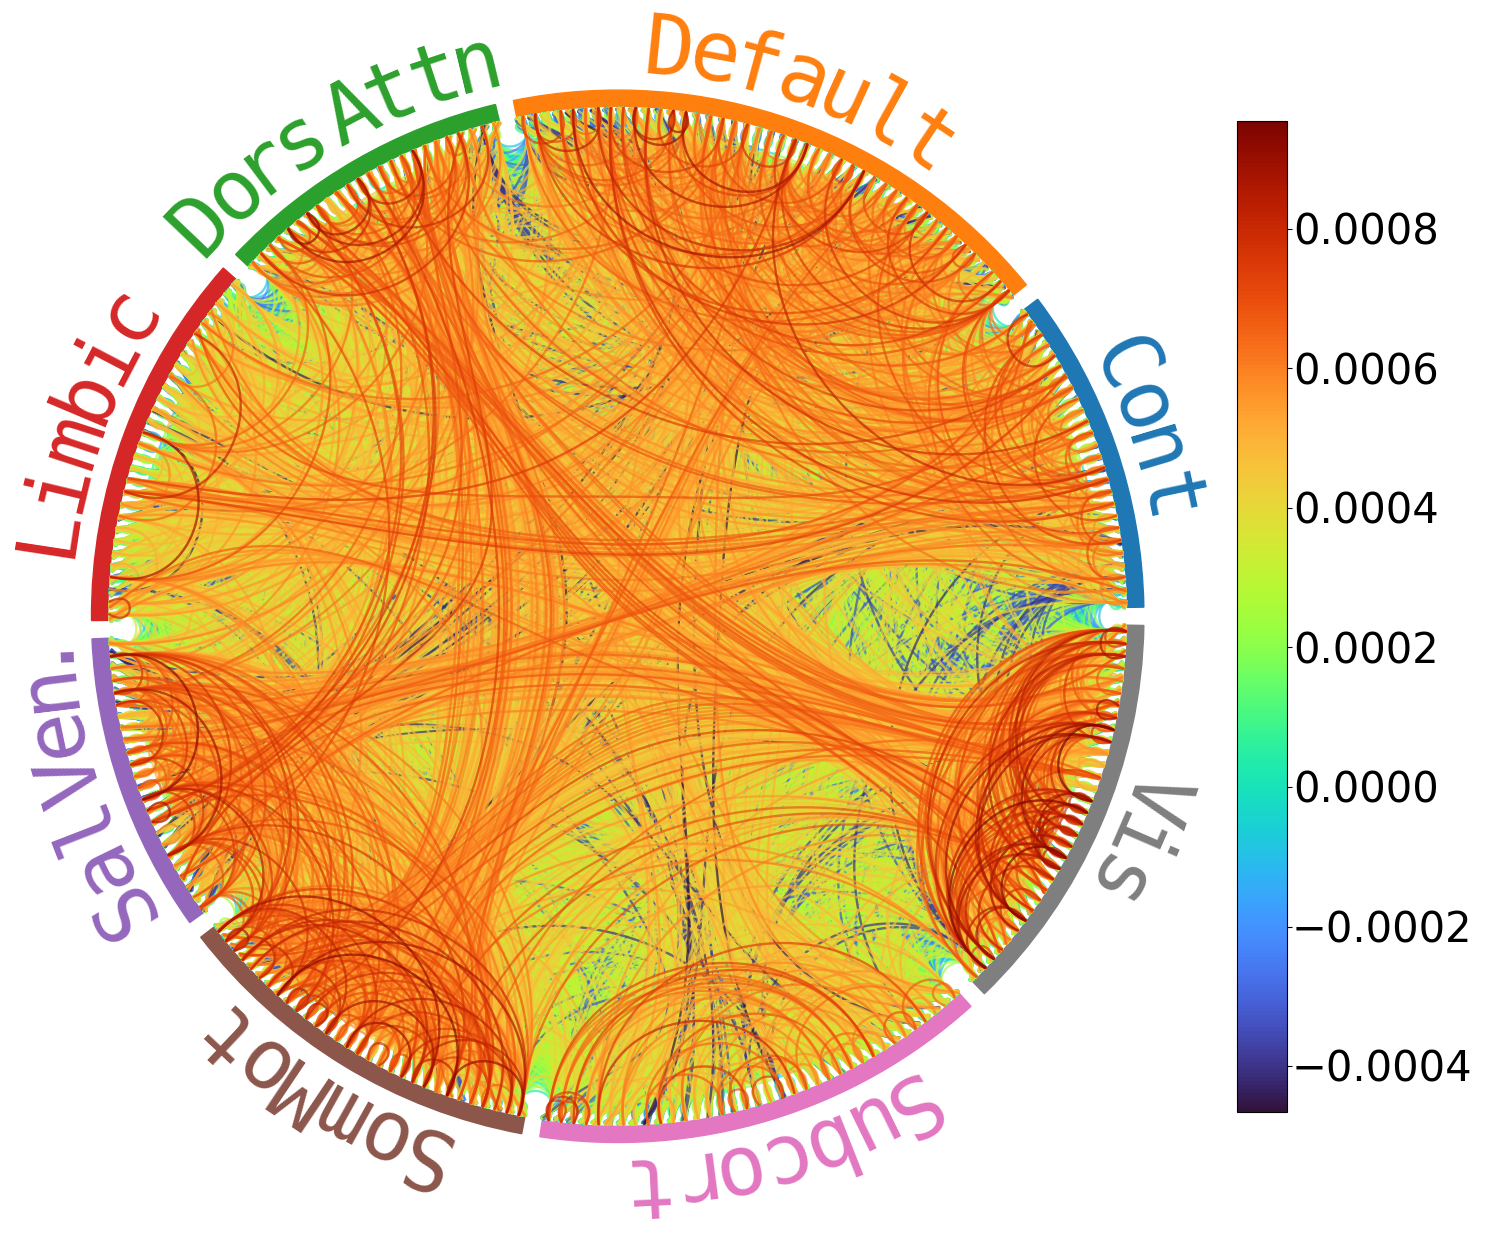

In [22]:

# Function to load all subject connection matrices
def load_conn_matrices(subjects, conn_file_func):
    conn_matrices = []
    for subject in subjects:
        conn_matrix_path = conn_file_func(subject)
        conn_matrix = nib.load(conn_matrix_path).get_fdata()
        conn_matrices.append(conn_matrix)
    return np.array(conn_matrices)

# Function to load the labels (from a single label tsv)
def load_labels(label_file):
    df = pd.read_csv(label_file, sep='\t')
    if 'networks' in df.columns:
        idx_to_label = {idx: label for idx, label in zip(df.index, df.networks)}
    else:
        raise ValueError(f'No networks defined in {label_file}')
    return idx_to_label

# Function to calculate the average connection matrix
def average_conn_matrix(conn_matrices):
    return np.mean(conn_matrices, axis=0)

# Define the subjects for each dataset
lobe_subjects = ['007', '009', '013']  # Replace with actual subject names for LOBE
hcp_subjects = ['HCD2901654', 'HCD0551946', 'HCD1010412']  # Replace with actual subject names for HCP

# Define file paths (customize as needed)
lobe_label_file = 'resources/atlas/atlas-brainnetome_dseg.tsv'  # LOBE label file
hcp_label_file = 'resources/atlas/atlas-brainnetome_dseg.tsv'   # HCP label file
lobe_conn_file_func = lambda subject: f'results/LOBE/sub-{subject}/func/sub-{subject}_task-rest_den-91k_desc-preproc_denoise-24HMP8PhysSpikeReg_fwhm-5_atlas-brainnetome_bold.pconn.nii'
hcp_conn_file_func = lambda subject: f'results/HCP/sub-{subject}/func/sub-{subject}_task-rest_den-91k_desc-preproc_denoise-24HMP8PhysSpikeReg_fwhm-5_atlas-brainnetome_bold.pconn.nii'

# Load the labels for LOBE and HCP datasets
lobe_labels = load_labels(lobe_label_file)
hcp_labels = load_labels(hcp_label_file)

# Load connection matrices for all subjects in each dataset
lobe_conn_matrices = load_conn_matrices(lobe_subjects, lobe_conn_file_func)
hcp_conn_matrices = load_conn_matrices(hcp_subjects, hcp_conn_file_func)

# Compute the average connectivity matrix for each dataset
lobe_avg_conn = average_conn_matrix(lobe_conn_matrices)
hcp_avg_conn = average_conn_matrix(hcp_conn_matrices)

# Plot the chord diagrams for each dataset
opts = {
    'edge_widthscale': 0.001,  # Example option, customize as needed
    'edge_threshold': 100,
    'view': 'LSc',
    'edge_thresolddirection': 'above',
    'figsize': (10, 10)
}

# Convert the average connectivity matrices for both LOBE and HCP
lobe_edges, lobe_edge_weights = convert_matrix(lobe_avg_conn)
hcp_edges, hcp_edge_weights = convert_matrix(hcp_avg_conn)

# Apply the edge width scaling
lobe_edge_weights = lobe_edge_weights * opts['edge_widthscale']
hcp_edge_weights = hcp_edge_weights * opts['edge_widthscale']

# Define output paths for the plots
lobe_output_path = 'lobe_avg_chord_plot.png'  # Path to save LOBE plot
hcp_output_path = 'hcp_avg_chord_plot.png'    # Path to save HCP plot

# Plot the chord diagrams for LOBE and HCP
plot_chord(idx_to_label=lobe_labels, edges=lobe_edges, edge_weights=lobe_edge_weights, fp_chord=lobe_output_path)
plot_chord(idx_to_label=hcp_labels, edges=hcp_edges, edge_weights=hcp_edge_weights, fp_chord=hcp_output_path)

# Print paths of saved plots
print(f"Chord plot for LOBE dataset saved at: {lobe_output_path}")
print(f"Chord plot for HCP dataset saved at: {hcp_output_path}")


# Func Net #

In [23]:

# Function to load all subject connection matrices
def load_conn_matrices(subjects, conn_file_func):
    conn_matrices = []
    for subject in subjects:
        conn_matrix_path = conn_file_func(subject)
        conn_matrix = nib.load(conn_matrix_path).get_fdata()
        conn_matrices.append(conn_matrix)
    return np.array(conn_matrices)

# Function to load the labels (from a single label tsv)
def load_labels(label_file):
    df = pd.read_csv(label_file, sep='\t')
    if 'networks' in df.columns:
        idx_to_label = {idx: label for idx, label in zip(df.index, df.networks)}
    else:
        raise ValueError(f'No networks defined in {label_file}')
    return idx_to_label

# Function to calculate the average connection matrix
def average_conn_matrix(conn_matrices):
    return np.mean(conn_matrices, axis=0)

# Define the subjects for each dataset
lobe_subjects = ['007', '009', '013']  # Replace with actual subject names for LOBE
hcp_subjects = ['HCD2901654', 'HCD0551946', 'HCD1010412']  # Replace with actual subject names for HCP

# Define file paths (customize as needed)
lobe_label_file = 'resources/atlas/atlas-brainnetome_dseg.tsv'  # LOBE label file
hcp_label_file = 'resources/atlas/atlas-brainnetome_dseg.tsv'   # HCP label file
lobe_conn_file_func = lambda subject: f'results/LOBE/sub-{subject}/func/sub-{subject}_task-rest_den-91k_desc-preproc_denoise-24HMP8PhysSpikeReg_fwhm-5_atlas-brainnetome_netbold.pconn.nii'
hcp_conn_file_func = lambda subject: f'results/HCP/sub-{subject}/func/sub-{subject}_task-rest_den-91k_desc-preproc_denoise-24HMP8PhysSpikeReg_fwhm-5_atlas-brainnetome_netbold.pconn.nii'

# Load the labels for LOBE and HCP datasets
lobe_labels = load_labels(lobe_label_file)
hcp_labels = load_labels(hcp_label_file)

# Load connection matrices for all subjects in each dataset
lobe_conn_matrices = load_conn_matrices(lobe_subjects, lobe_conn_file_func)
hcp_conn_matrices = load_conn_matrices(hcp_subjects, hcp_conn_file_func)

# Compute the average connectivity matrix for each dataset
lobe_avg_conn = average_conn_matrix(lobe_conn_matrices)
hcp_avg_conn = average_conn_matrix(hcp_conn_matrices)

# Plot the chord diagrams for each dataset
opts = {
    'edge_widthscale': 0.001,  # Example option, customize as needed
    'edge_threshold': 100,
    'view': 'LSc',
    'edge_thresolddirection': 'above',
    'figsize': (10, 10)
}

# Convert the average connectivity matrices for both LOBE and HCP
lobe_edges, lobe_edge_weights = convert_matrix(lobe_avg_conn)
hcp_edges, hcp_edge_weights = convert_matrix(hcp_avg_conn)

# Apply the edge width scaling
lobe_edge_weights = lobe_edge_weights * opts['edge_widthscale']
hcp_edge_weights = hcp_edge_weights * opts['edge_widthscale']

# Define output paths for the plots
lobe_output_path = 'lobe_avg_chord_plot.png'  # Path to save LOBE plot
hcp_output_path = 'hcp_avg_chord_plot.png'    # Path to save HCP plot

# Plot the chord diagrams for LOBE and HCP
plot_chord(idx_to_label=lobe_labels, edges=lobe_edges, edge_weights=lobe_edge_weights, fp_chord=lobe_output_path)
plot_chord(idx_to_label=hcp_labels, edges=hcp_edges, edge_weights=hcp_edge_weights, fp_chord=hcp_output_path)

# Print paths of saved plots
print(f"Chord plot for LOBE dataset saved at: {lobe_output_path}")
print(f"Chord plot for HCP dataset saved at: {hcp_output_path}")


Chord plot for LOBE dataset saved at: lobe_avg_chord_plot.png
Chord plot for HCP dataset saved at: hcp_avg_chord_plot.png


<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

In [51]:
df = pd.read_csv('resources/dataset-HCP_tabular.tsv', sep='\t')
# Calculate the mean (average) of the 'age' column
mean_asm = df['age'].mean()
print(f'The mean of the asm column is: {mean_asm}')
std_age = df['age'].std()
print(f'The standard deviation of the age column is: {std_age}')


The mean of the asm column is: 13.152003910068425
The standard deviation of the age column is: 2.872677531727475


In [49]:
import pandas as pd
# Load the dataset
df = pd.read_csv('resources/dataset-LOBE_tabular.tsv', sep='\t')
# Calculate the mean (average) of the 'age' column
mean_asm = df['asm_first_scan'].mean()
print(f'The mean of the asm column is: {mean_asm}')






The mean of the asm column is: 2.16


In [44]:
# Calculate the standard deviation of the 'age' column
std_age = df['asm_first_scan'].std()
print(f'The standard deviation of the age column is: {std_age}')

The standard deviation of the age column is: 1.106044001535804


In [46]:
index=12

In [50]:
# Drop row with index 12 (which corresponds to row 13) and calculate standard deviation
df_without_row_13 = df.drop(index=12)

# Calculate standard deviation for the 'asm' column, ignoring row 13
mean_asm = df['age'].mean()
print(f'The mean of the asm column is: {mean_asm}')

std_asm_without_row_13 = df_without_row_13['age'].std()
print(f'The standard deviation of the asm column (ignoring row 13) is: {std_asm_without_row_13}')


The mean of the asm column is: 12.115384615384615
The standard deviation of the asm column (ignoring row 13) is: 3.527510926040249


In [48]:
df_without_row_13

,participant_id,age,sex,age_seizure_onset,age_ep_diagnosis,ep_duration_first_scan,seizure_duration_first_scan,pnes,benign_rolandic,genetic_cause,...,loc_pet_occipital,loc_pet_parietal,loc_pet_temporal,loc_semiology,loc_final_frontal,loc_final_occipital,loc_final_parietal,loc_final_temporal,loc_final_temporal_plus,loc_final_extratemporal
0,sub-004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-006,9.0,M,7.0,8.0,1.0,2.0,0.0,0.0,NaN,...,0.0,1.0,0.0,peri-sylvia opercular,0,0,1,0,0.0,0.0
2,sub-007,9.0,F,7.0,7.0,2.0,2.0,0.0,0.0,NaN,...,0.0,0.0,1.0,NaN,0,0,0,1,0.0,0.0
3,sub-009,8.0,M,2.0,8.0,0.0,6.0,0.0,0.0,NPRL3,...,NaN,NaN,NaN,temporal insular,0,0,0,1,1.0,0.0
4,sub-010,15.0,M,7.0,7.0,8.0,8.0,0.0,0.0,NaN,...,NaN,NaN,NaN,frontal,1,0,0,0,0.0,0.0
5,sub-012,14.0,F,4.0,10.0,4.0,10.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,0,1,0,1,0.0,0.0
6,sub-013,15.0,F,13.0,14.0,1.0,2.0,0.0,0.0,NaN,...,0.0,0.0,1.0,NaN,0,0,0,1,0.0,0.0
7,sub-014,14.0,M,9.0,9.0,5.0,5.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,0,0,0,1,0.0,0.0
8,sub-015,10.0,M,7.0,7.0,3.0,3.0,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,0,0,0,0,0.0,1.0
9,sub-017,15.0,F,10.0,10.0,5.0,5.0,0.0,0.0,KCNQ1,...,NaN,NaN,NaN,NaN,unknown,unknown,unknown,unknown,NaN,NaN
